In [ ]:
import numpy as np
import xarray as xr
import sys
sys.path.append('/home/qianyk/OneDrive/Python/MyPack/xdispersion/')
import warnings
warnings.filterwarnings("ignore")

"""
Generate reference measure NC files for testing.

This script computes all measures via ``cal_measures`` for three datasets
and saves the results as compressed NetCDF files (zlib) suitable for
uploading to GitHub.

Usage::

    cd xdispersion
    python tests/generate_ref.py

The generated files are::

    data/ref_measures_ragged.nc    — GLAD drifters   (ragged,  latlon)
    data/ref_measures_local.nc     — Particles_local (non-ragged, cartesian)
    data/ref_measures_nonlocal.nc  — Particles_nonlocal (non-ragged, cartesian)

Each file contains ~42 variables (const-t, const-r, and derived measures)
computed with ``ensemble=0`` (no bootstrapping).
"""
import os
from xdispersion.core import RelativeDispersion
from xdispersion.template import cal_measures
from xdispersion.utils import gen_rbins


rbins = gen_rbins(0.01, 1000, alpha=1.2)


def save_nc(ds, path):
    """Save *ds* as a zlib-compressed NetCDF file."""
    encoding = {v: {'zlib': True, 'complevel': 5} for v in ds.data_vars}
    ds.to_netcdf(path, encoding=encoding)
    size = os.path.getsize(path)
    print(f'  saved {path}  ({size / 1024:.1f} KB)')


# --------------------------------------------------------------------------- #
def generate_ragged():
    """GLAD drifters — ragged, latlon coordinates."""
    print('Generating reference for ragged (GLAD) ...')
    dset = xr.open_dataset('../data/glad32.nc')
    rd = RelativeDispersion(dset, xpos='longitude', ypos='latitude',
                            uvel='ve', vvel='vn', maxtlen=4 * 24 * 80,
                            time='time', Rearth=6371.2, ID='traj',
                            coord='latlon', ragged=True, chunk=50)
    p_all = rd.get_all_pairs()
    pairs = rd.get_original_pairs(p_all, r0=[0.08, 0.18])
    print(f'  {len(pairs.pair)} original pairs')
    ref = cal_measures(rd, pairs, rbins, one_by_one=True)
    save_nc(ref, '../data/ref_measures_ragged.nc')


def generate_local():
    """Particles_local — non-ragged, cartesian coordinates."""
    print('Generating reference for local (Particles_local) ...')
    dset = xr.open_dataset('../data/Particles_local.nc')
    rd = RelativeDispersion(dset, xpos='xpos', ypos='ypos',
                            uvel='uvel', vvel='vvel',
                            time='time', ID='ID',
                            coord='cartesian', ragged=False, chunk=200)
    p_all = rd.get_all_pairs()
    pairs = rd.get_original_pairs(p_all, r0=[0, 0.01])
    print(f'  {len(pairs.pair)} original pairs')
    ref = cal_measures(rd, pairs, rbins, one_by_one=True)
    save_nc(ref, '../data/ref_measures_local.nc')


def generate_nonlocal():
    """Particles_nonlocal — non-ragged, cartesian coordinates."""
    print('Generating reference for nonlocal (Particles_nonlocal) ...')
    dset = xr.open_dataset('../data/Particles_nonlocal.nc')
    rd = RelativeDispersion(dset, xpos='xpos', ypos='ypos',
                            uvel='uvel', vvel='vvel',
                            time='time', ID='ID',
                            coord='cartesian', ragged=False, chunk=200)
    p_all = rd.get_all_pairs()
    pairs = rd.get_original_pairs(p_all, r0=[0, 0.01])
    print(f'  {len(pairs.pair)} original pairs')
    ref = cal_measures(rd, pairs, rbins, one_by_one=True)
    save_nc(ref, '../data/ref_measures_nonlocal.nc')


generate_ragged()
generate_local()
generate_nonlocal()
print('Done!')


Generating reference for ragged (GLAD) ...
there are 43518 pairs of particles
  171 original pairs


100%|███████████████████████████████████████████| 42/42 [00:00<00:00, 42.29it/s]


  saved ../data/GLAD_measures_ragged.nc  (616.2 KB)
Generating reference for local (Particles_local) ...
  2920 original pairs


100%|███████████████████████████████████████████| 42/42 [00:05<00:00,  7.58it/s]


  saved ../data/Synthetic_measures_local.nc  (252.2 KB)
Generating reference for nonlocal (Particles_nonlocal) ...
  2920 original pairs


100%|███████████████████████████████████████████| 42/42 [00:05<00:00,  7.73it/s]


  saved ../data/Synthetic_measures_nonlocal.nc  (250.0 KB)
Done!


In [2]:
import xarray as xr

ds = xr.open_dataset('../data/GLAD_measures_ragged.nc')
ds

<xarray.Dataset> Size: 682kB
Dimensions:  (rtime: 7680, rbin: 64)
Coordinates:
  * rtime    (rtime) float64 61kB 0.0 0.01042 0.02083 ... 79.97 79.98 79.99
  * rbin     (rbin) float32 256B 0.01 0.012 0.0144 0.01728 ... 676.2 811.4 973.7
Data variables: (12/42)
    r2_t     (rtime) float32 31kB ...
    rpb2_t   (rtime) float32 31kB ...
    S2_t     (rtime) float32 31kB ...
    S2ll_t   (rtime) float32 31kB ...
    S2tr_t   (rtime) float32 31kB ...
    S3_t     (rtime) float32 31kB ...
    ...       ...
    LAC_r    (rbin) float32 256B ...
    CVE_r    (rbin) float32 256B ...
    FSLE_r   (rbin) float32 256B ...
    CIST_r   (rbin) float32 256B ...
    S2rr_r   (rbin) float32 256B ...
    S2dd_r   (rbin) float32 256B ...
Attributes:
    comment:  relative dispersion averaged at constant time

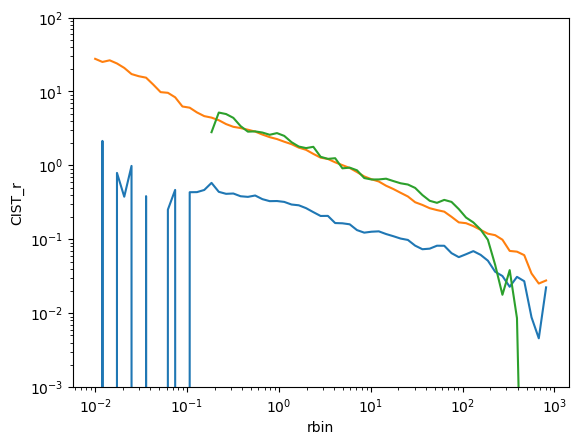

In [8]:
ds.FAGR_r.plot(xscale='log', yscale='log', ylim=[1e-3, 1e2])
ds.FAGRp_r.plot()
ds.CIST_r.plot()